# AIWP-driven StormScope nowcasting over Wyoming

This notebook chains a global **AI weather prediction (AIWP)** model into **StormScope**,
NVIDIA's diffusion-based satellite/radar nowcaster, and looks at the result over **Wyoming**.

Pipeline:

1. **AIWP stage** – FourCastNet 3 (FCN3) initialised from GFS analysis, wrapped with the
   `InterpModAFNO` temporal interpolator so we get hourly output, and with a surface-pressure
   diagnostic so the interpolator has all 73 channels it needs. We keep only `z500`.
2. **StormScope GOES** (`6km_1hr` variant) – forecasts eight GOES ABI channels on the 6 km
   HRRR grid. This variant is *conditioned on synoptic-scale `z500`*, which is exactly where
   the AIWP forecast plugs in (replacing the GFS forecast normally used).
3. **StormScope MRMS** (`6km_1hr` variant) – forecasts composite reflectivity, conditioned on
   the GOES imagery that the GOES model produced in the same rollout step.
4. **Wyoming analysis** – zoomed maps, a small verification against observed MRMS, and a NetCDF
   export of the Wyoming cut-out.

Notes

* StormScope is a CONUS model on a fixed grid; "over Wyoming" therefore means we run the full
  CONUS domain and analyse/crop the Wyoming sub-region (41–45°N, 104–111°W).
* Only the `6km_1hr` StormScope variant takes external `z500` conditioning. The newer
  `3km_10min` nowcaster is "pure observation" and cannot be coupled to an AIWP model, so the
  legacy variant is used on purpose (you will see a deprecation warning when it loads).
* Runtime: FCN3 + interpolation is fast; each StormScope step is a 100-step diffusion sample for
  two models, roughly a minute per hour of forecast on a single GB200/H100.

Environment used to build this notebook: `venvs/earth2studio` (earth2studio fork at
`forks/earth2studio`, NATTEN with libnatten, `earth2studio[fcn3,stormscope]` extras, cartopy).


## Setup

In [1]:
import os
from collections import OrderedDict
from datetime import datetime

os.makedirs("outputs", exist_ok=True)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from tqdm.auto import tqdm

from earth2studio.data import GFS, GOES, MRMS, InferenceOutputSource, fetch_data
from earth2studio.io import XarrayBackend
from earth2studio.models.dx import DerivedSurfacePressure
from earth2studio.models.px import FCN3, DiagnosticWrapper, InterpModAFNO
from earth2studio.models.px.stormscope import StormScopeBase, StormScopeGOES, StormScopeMRMS
from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

/lustre/fs1/portfolios/coreai/projects/coreai_modulus_cae/users/nsobhani/venvs/earth2studio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
cuda NVIDIA GB200


## Case configuration

A summer afternoon on the High Plains. FCN3 runs from the 12 UTC GFS analysis; StormScope is
initialised six hours later at 18 UTC (noon local) from GOES-16 and MRMS observations and run
for six hourly steps into the evening convective period.


In [2]:
START_TIME_AIWP = datetime(2024, 7, 17, 12)        # FCN3 init: must be on a 6 h boundary
START_TIME_STORMSCOPE = datetime(2024, 7, 17, 18)  # StormScope init: hourly, >= AIWP init
N_STEPS = 6                                        # hourly StormScope steps
SEED = 1234

# Wyoming bounding box (degrees; lon in [-180, 180])
WY = dict(lat_min=41.0, lat_max=45.0, lon_min=-111.05, lon_max=-104.05)

# Major Wyoming cities/towns to mark on the maps: name -> (lat, lon)
WY_CITIES = {
    "Cheyenne": (41.140, -104.820),
    "Laramie": (41.311, -105.591),
    "Casper": (42.867, -106.313),
    "Gillette": (44.291, -105.502),
    "Rock Springs": (41.587, -109.203),
    "Sheridan": (44.797, -106.956),
    "Jackson": (43.480, -110.762),
    "Evanston": (41.268, -110.963),
    "Riverton": (43.025, -108.380),
    "Cody": (44.526, -109.056),
}

time_aiwp = to_time_array([START_TIME_AIWP])
time_ss = to_time_array([START_TIME_STORMSCOPE])
lead_times = np.array([np.timedelta64(i, "h") for i in range(N_STEPS + 1)])
model_gap_h = int((time_ss[0] - time_aiwp[0]) / np.timedelta64(1, "h"))
assert model_gap_h >= 0 and model_gap_h % 1 == 0
print(f"AIWP init {START_TIME_AIWP}  ->  StormScope init {START_TIME_STORMSCOPE} (gap {model_gap_h} h), {N_STEPS} steps")

AIWP init 2024-07-17 12:00:00  ->  StormScope init 2024-07-17 18:00:00 (gap 6 h), 6 steps


## 1. AIWP stage: FCN3 with hourly interpolation

`InterpModAFNO` needs surface pressure, which FCN3 does not predict, so FCN3 is wrapped with a
`DerivedSurfacePressure` diagnostic (hydrostatic interpolation from geopotential and temperature)
before being handed to the interpolator. This mirrors the FCN3+StormScope serving workflow in
earth2studio.


In [3]:
package_fcn3 = FCN3.load_default_package()
fcn3 = FCN3.load_model(package_fcn3)

with xr.open_dataset(package_fcn3.resolve("orography.nc")) as ds:
    z_surface = torch.as_tensor(ds["Z"][0].values)
z_surf_coords = OrderedDict({d: fcn3.input_coords()[d] for d in ["lat", "lon"]})
sp_model = DerivedSurfacePressure(
    p_levels=[50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
    surface_geopotential=z_surface,
    surface_geopotential_coords=z_surf_coords,
)
fcn3_sp = DiagnosticWrapper(px_model=fcn3, dx_model=sp_model)

aiwp = InterpModAFNO.from_pretrained()
aiwp.px_model = fcn3_sp
aiwp = aiwp.to(device).eval()

aiwp_out_coords = aiwp.output_coords(aiwp.input_coords())
lat_aiwp, lon_aiwp = aiwp_out_coords["lat"], aiwp_out_coords["lon"]
print("AIWP output grid:", lat_aiwp.shape, lon_aiwp.shape, "| variables:", len(aiwp_out_coords["variable"]))

AIWP output grid: (720,) (1440,) | variables: 73


In [4]:
x_aiwp, coords_aiwp = fetch_data(
    GFS(),
    time=time_aiwp,
    variable=aiwp.input_coords()["variable"],
    device=device,
)
print(x_aiwp.shape, {k: v.shape for k, v in coords_aiwp.items()})

Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

2026-09-01 22:25:48.173 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 196474537-594545


Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

...

Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

2026-09-01 22:25:48.983 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 212199457-774266
2026-09-01 22:25:48.993 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 239536735-605405
2026-09-01 22:25:49.096 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 297003766-839663
2026-09-01 22:25:49.099 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 193613249-983011
2026-09-01 22:25:49.110 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 417564732-1236596
2026-09-01 22:25:49.120 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   1%|▏         | 1/72 [00:01<01:11,  1.01s/it]

Fetching GFS data: 100%|██████████| 72/72 [00:01<00:00, 70.47it/s]

torch.Size([1, 1, 72, 721, 1440]) {'time': (1,), 'lead_time': (1,), 'variable': (72,), 'lat': (721,), 'lon': (1440,)}


Run the interpolated FCN3 forecast far enough to cover the StormScope window and store the
hourly `z500` fields in an in-memory `XarrayBackend`. Time coordinates are re-based so that
`time` is the StormScope initialisation and `lead_time` runs 0…N h; this is what StormScope will
query for conditioning.


In [5]:
z500_var = np.array(["z500"])
io_aiwp = XarrayBackend()
io_aiwp.add_array(
    OrderedDict(time=time_ss, lead_time=lead_times, lat=lat_aiwp, lon=lon_aiwp), z500_var
)

fcn3.set_rng(seed=SEED)
n_total = model_gap_h + N_STEPS
for step, (x, cx) in tqdm(
    enumerate(aiwp.create_iterator(x_aiwp.clone(), coords_aiwp.copy())),
    total=n_total + 1, desc="FCN3 + InterpModAFNO (hourly)",
):
    if step >= model_gap_h:
        x, cx = map_coords(x, cx, OrderedDict({"variable": z500_var}))
        cx = cx.copy()
        cx["time"] = time_ss
        cx["lead_time"] = cx["lead_time"] - np.timedelta64(model_gap_h, "h")
        io_aiwp.write(*split_coords(x, cx))
    if step == n_total:
        break

ds_z500 = io_aiwp.root
ds_z500

FCN3 + InterpModAFNO (hourly):   0%|          | 0/13 [00:00<?, ?it/s]

FCN3 + InterpModAFNO (hourly):   8%|▊         | 1/13 [00:00<00:02,  4.08it/s]

FCN3 + InterpModAFNO (hourly):  15%|█▌        | 2/13 [00:10<01:08,  6.19s/it]

FCN3 + InterpModAFNO (hourly):  23%|██▎       | 3/13 [00:10<00:34,  3.46s/it]

FCN3 + InterpModAFNO (hourly):  31%|███       | 4/13 [00:11<00:19,  2.18s/it]

...

FCN3 + InterpModAFNO (hourly):  77%|███████▋  | 10/13 [00:13<00:01,  1.95it/s]

FCN3 + InterpModAFNO (hourly):  85%|████████▍ | 11/13 [00:13<00:00,  2.34it/s]

FCN3 + InterpModAFNO (hourly):  92%|█████████▏| 12/13 [00:13<00:00,  2.73it/s]

FCN3 + InterpModAFNO (hourly):  92%|█████████▏| 12/13 [00:13<00:01,  1.13s/it]

<xarray.Dataset> Size: 58MB
Dimensions:    (time: 1, lead_time: 7, lat: 720, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-07-17T18:00:00
  * lead_time  (lead_time) timedelta64[s] 56B 00:00:00 01:00:00 ... 06:00:00
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables:
    z500       (time, lead_time, lat, lon) float64 58MB 5.296e+04 ... 4.92e+04

## 2. StormScope models conditioned on the AIWP forecast

In [6]:
# Expose the stored AIWP z500 as an earth2studio data source keyed by valid time
z500_source = InferenceOutputSource(ds_z500)

package_ss = StormScopeBase.load_default_package()
print(StormScopeGOES.list_available_models(package_ss))

# GOES model: conditioned on z500 -> conditioning source is the AIWP forecast
model_goes = StormScopeGOES.load_model(
    package=package_ss, model_name="6km_1hr", conditioning_data_source=z500_source, amp=True
).to(device).eval()

# MRMS model: conditioned on GOES, which we pass explicitly during the coupled rollout
model_mrms = StormScopeMRMS.load_model(
    package=package_ss, model_name="6km_1hr", conditioning_data_source=None, amp=True
).to(device).eval()

print("GOES state:", model_goes.variables, "| conditioning:", model_goes.conditioning_variables)
print("MRMS state:", model_mrms.variables, "| conditioning:", model_mrms.conditioning_variables)
print("Model grid:", tuple(model_goes.latitudes.shape))

{'3km_10min': {'description': 'CONUS nowcasting - 3 km / 10 min (recommended)', 'deprecated': False}, '6km_1hr': {'description': '6 km / 60 min nearcasting (legacy)', 'deprecated': True}}
2026-09-01 22:26:02.901 | WARNING  | earth2studio.models.px.stormscope:_resolve_model_entry:361 - StormScope '6km_1hr' is a legacy (nearcasting) checkpoint kept for backwards compatibility; the supported defaults are the CONUS nowcasting variants. See list_available_models() for alternatives.


2026-09-01 22:26:05.711 | WARNING  | earth2studio.models.px.stormscope:_resolve_model_entry:361 - StormScope '6km_1hr' is a legacy (nearcasting) checkpoint kept for backwards compatibility; the supported defaults are the CONUS nowcasting variants. See list_available_models() for alternatives.


2026-09-01 22:26:08.463 | WARNING  | earth2studio.models.px.stormscope:__init__:193 - No conditioning data source was provided to StormScope; set the conditioning_data_source attribute of the model before running inference with iterator mode, or use the call_with_conditioning method.
GOES state: ['abi01c' 'abi02c' 'abi03c' 'abi07c' 'abi08c' 'abi09c' 'abi10c' 'abi13c'] | conditioning: ['z500']
MRMS state: ['refc'] | conditioning: ['abi01c' 'abi02c' 'abi03c' 'abi07c' 'abi08c' 'abi09c' 'abi10c' 'abi13c']
Model grid: (512, 896)


### Initial conditions and regridding

StormScope works on a (downsampled) HRRR Lambert-conformal grid. Each model owns nearest-neighbour
interpolators: one for its own state (GOES or MRMS native grid → model grid) and one for its
conditioning (the AIWP 0.25° lat/lon grid for GOES; the GOES grid for MRMS).


In [7]:
goes_sat, scan_mode = "goes16", "C"   # GOES-16 was GOES-East in 2024 (GOES-19 from April 2025)
goes = GOES(satellite=goes_sat, scan_mode=scan_mode)
goes_lat, goes_lon = GOES.grid(satellite=goes_sat, scan_mode=scan_mode)

model_goes.build_input_interpolator(goes_lat, goes_lon)
model_goes.build_conditioning_interpolator(lat_aiwp, lon_aiwp)

in_coords_goes = model_goes.input_coords()
x_goes, coords_goes = fetch_data(
    goes, time=time_ss, variable=in_coords_goes["variable"],
    lead_time=in_coords_goes["lead_time"], device=device,
)

mrms = MRMS()
in_coords_mrms = model_mrms.input_coords()
x_mrms, coords_mrms = fetch_data(
    mrms, time=time_ss, variable=in_coords_mrms["variable"],
    lead_time=in_coords_mrms["lead_time"], device=device,
)
model_mrms.build_input_interpolator(coords_mrms["lat"], coords_mrms["lon"])
model_mrms.build_conditioning_interpolator(goes_lat, goes_lon)

# Add the batch dimension [B, T, L, C, H, W]; B>1 would give an ensemble
for name in ("goes", "mrms"):
    x, c = (x_goes, coords_goes) if name == "goes" else (x_mrms, coords_mrms)
    if x.dim() == 5:
        x = x.unsqueeze(0)
        c["batch"] = np.arange(1)
        c.move_to_end("batch", last=False)
    x = x.to(torch.float32)
    if name == "goes":
        x_goes, coords_goes = x, c
    else:
        x_mrms, coords_mrms = x, c
print("GOES IC", tuple(x_goes.shape), "| MRMS IC", tuple(x_mrms.shape))

2026-09-01 22:26:10.569 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (0.0).


Fetching GOES data:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching GOES data:   0%|          | 0/1 [00:01<?, ?it/s]

2026-09-01 22:26:14.354 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes16/ABI-L2-MCMIPC/2024/199/18/OR_ABI-L2-MCMIPC-M6_G16_s20241991801180_e20241991803565_c20241991804073.nc


Fetching GOES data: 100%|██████████| 1/1 [00:02<00:00,  2.34s/it]

...

2026-09-01 22:26:18.326 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240717/MRMS_MergedReflectivityQCComposite_00.50_20240717-180041.grib2.gz


Fetching MRMS data: 100%|██████████| 1/1 [00:05<00:00,  5.11s/it]

Fetching MRMS data: 100%|██████████| 1/1 [00:05<00:00,  5.11s/it]

2026-09-01 22:26:28.455 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (-0.25285158).


2026-09-01 22:26:29.960 | WARNING  | earth2studio.models.px.stormscope:build_conditioning_interpolator:689 - Some conditioning gridpoints are invalid after interpolation. This may be expected if the conditioning data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (-0.25285158).
GOES IC (1, 1, 1, 8, 1500, 2500) | MRMS IC (1, 1, 1, 1, 3500, 7000)


### Coupled rollout

Each hour: the GOES model advances the satellite state (it fetches the AIWP `z500` for the
current valid time internally through its conditioning source), then the MRMS model advances the
radar state conditioned on the *current* GOES state. Predictions are collected on the model grid.


In [8]:
lat_m = model_goes.latitudes.cpu().numpy()
lon_m = model_goes.longitudes.cpu().numpy()
lon_m180 = np.where(lon_m > 180, lon_m - 360, lon_m)
i_ir = list(model_goes.variables).index("abi13c")
i_refc = list(model_mrms.variables).index("refc")

torch.manual_seed(SEED)
y, yc = x_goes, coords_goes
ym, ymc = x_mrms, coords_mrms

goes_frames, mrms_frames, valid_times = [], [], []
for step in tqdm(range(N_STEPS), desc="StormScope coupled rollout"):
    y_pred, y_pred_c = model_goes(y, yc)
    ym_pred, ym_pred_c = model_mrms.call_with_conditioning(ym, ymc, conditioning=y, conditioning_coords=yc)

    goes_frames.append(torch.where(model_goes.valid_mask, y_pred, torch.nan)[0, 0, 0].cpu())
    mrms_frames.append(torch.where(model_mrms.valid_mask, ym_pred, torch.nan)[0, 0, 0].cpu())
    valid_times.append(y_pred_c["time"][0] + y_pred_c["lead_time"][0])

    y, yc = model_goes.next_input(y_pred, y_pred_c, y, yc)
    ym, ymc = model_mrms.next_input(ym_pred, ym_pred_c, ym, ymc)

goes_fc = torch.stack(goes_frames).numpy()   # [N_STEPS, C_goes, H, W]
mrms_fc = torch.stack(mrms_frames).numpy()   # [N_STEPS, C_mrms, H, W]
valid_times = np.array(valid_times)
print(goes_fc.shape, mrms_fc.shape, valid_times)

StormScope coupled rollout:   0%|          | 0/6 [00:00<?, ?it/s]

StormScope coupled rollout:  17%|█▋        | 1/6 [00:15<01:19, 15.92s/it]

StormScope coupled rollout:  33%|███▎      | 2/6 [00:31<01:02, 15.72s/it]

StormScope coupled rollout:  50%|█████     | 3/6 [00:47<00:46, 15.66s/it]

StormScope coupled rollout:  67%|██████▋   | 4/6 [01:02<00:31, 15.63s/it]

StormScope coupled rollout:  83%|████████▎ | 5/6 [01:18<00:15, 15.62s/it]

StormScope coupled rollout: 100%|██████████| 6/6 [01:33<00:00, 15.61s/it]

StormScope coupled rollout: 100%|██████████| 6/6 [01:33<00:00, 15.64s/it]

(6, 8, 512, 896) (6, 1, 512, 896) ['2024-07-17T19:00:00.000000000' '2024-07-17T20:00:00.000000000'
 '2024-07-17T21:00:00.000000000' '2024-07-17T22:00:00.000000000'
 '2024-07-17T23:00:00.000000000' '2024-07-18T00:00:00.000000000']


## 3. Wyoming analysis

### CONUS context with the Wyoming box


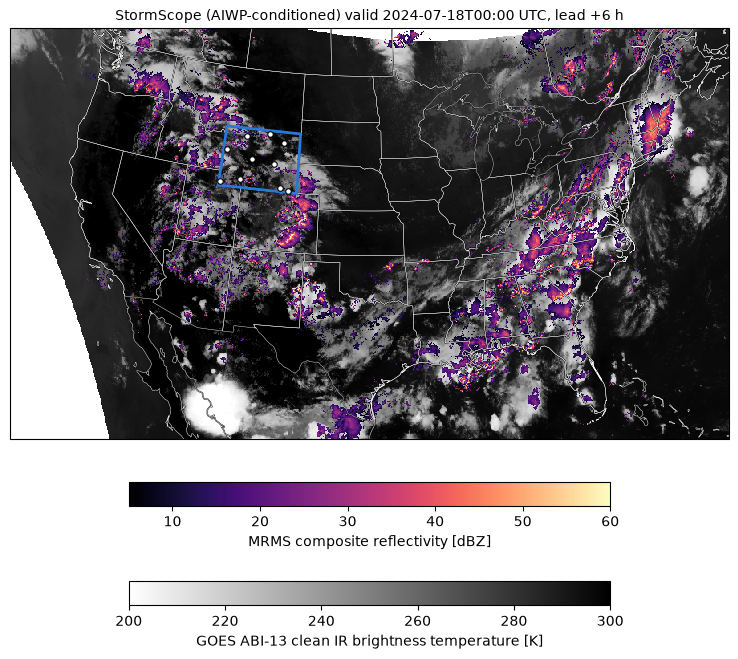

In [9]:
proj_hrrr = ccrs.LambertConformal(
    central_longitude=262.5, central_latitude=38.5, standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)
WY_EXTENT = [WY["lon_min"] - 0.5, WY["lon_max"] + 0.5, WY["lat_min"] - 0.5, WY["lat_max"] + 0.5]

def add_borders(ax):
    ax.coastlines(color="black", linewidth=1.0)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    ax.coastlines(color="white", linewidth=0.35)
    ax.add_feature(cfeature.STATES, edgecolor="white", linewidth=0.3)

def draw_wy_box(ax, **kw):
    lons = [WY["lon_min"], WY["lon_max"], WY["lon_max"], WY["lon_min"], WY["lon_min"]]
    lats = [WY["lat_min"], WY["lat_min"], WY["lat_max"], WY["lat_max"], WY["lat_min"]]
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), **kw)

def add_cities(ax, color="white", edge="black", fontsize=7, label=True):
    # Mark the Wyoming cities with a dot and (optionally) a name label
    for name, (lat, lon) in WY_CITIES.items():
        ax.plot(lon, lat, marker="o", markersize=4, markerfacecolor=color, markeredgecolor=edge,
                markeredgewidth=0.8, linestyle="none", transform=ccrs.PlateCarree(), zorder=10)
        if label:
            ax.annotate(name, xy=(lon, lat), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                        xytext=(4, 3), textcoords="offset points", fontsize=fontsize, color=color,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground=edge)], zorder=11)

def plot_goes_mrms(ax, ir, refc, title):
    im = ax.pcolormesh(lon_m, lat_m, ir, transform=ccrs.PlateCarree(), cmap="gray_r", shading="auto", vmin=200, vmax=300)
    refc_masked = np.where(refc <= 5, np.nan, refc)
    im2 = ax.pcolormesh(lon_m, lat_m, refc_masked, transform=ccrs.PlateCarree(), cmap="magma", shading="auto", vmin=5, vmax=60)
    add_borders(ax)
    ax.set_title(title, fontsize=10)
    return im, im2

k = N_STEPS - 1
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj_hrrr)
im, im2 = plot_goes_mrms(ax, goes_fc[k, i_ir], mrms_fc[k, i_refc],
                         f"StormScope (AIWP-conditioned) valid {str(valid_times[k])[:16]} UTC, lead +{k+1} h")
draw_wy_box(ax, color="#2a78d6", linewidth=2)
add_cities(ax, label=False)
plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.03, shrink=0.45, label="GOES ABI-13 clean IR brightness temperature [K]")
plt.colorbar(im2, ax=ax, orientation="horizontal", pad=0.08, shrink=0.45, label="MRMS composite reflectivity [dBZ]")
plt.tight_layout(); plt.savefig("outputs/conus_final_step.png", dpi=150); plt.show()

### AIWP conditioning: FCN3 `z500` over the western US

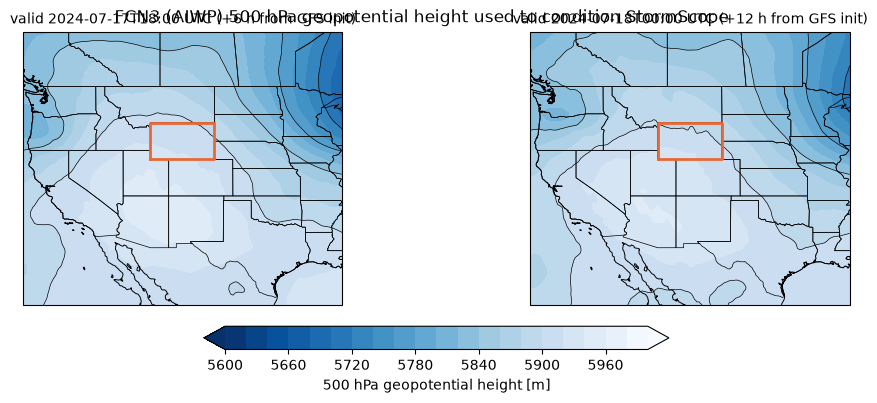

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
for ax, li in zip(axes, [0, N_STEPS]):
    z = ds_z500["z500"].isel(time=0, lead_time=li) / 9.80665  # geopotential -> geopotential height [m]
    z = z.sel(lat=slice(55, 25))
    z = z.assign_coords(lon=(((z.lon + 180) % 360) - 180)).sortby("lon").sel(lon=slice(-125, -90))
    cf = ax.contourf(z.lon, z.lat, z, levels=np.arange(5600, 6001, 20), cmap="Blues_r", extend="both")
    ax.contour(z.lon, z.lat, z, levels=np.arange(5600, 6001, 60), colors="black", linewidths=0.5)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.5)
    ax.coastlines(linewidth=0.7)
    draw_wy_box(ax, color="#eb6834", linewidth=2)
    vt = str(np.datetime64(time_ss[0]) + lead_times[li])[:16]
    ax.set_title(f"valid {vt} UTC (+{model_gap_h + li} h from GFS init)", fontsize=10)
fig.suptitle("FCN3 (AIWP) 500 hPa geopotential height used to condition StormScope", y=0.93)
fig.colorbar(cf, ax=axes, orientation="horizontal", shrink=0.5, pad=0.06, label="500 hPa geopotential height [m]")
plt.savefig("outputs/aiwp_z500.png", dpi=150); plt.show()

### Hourly Wyoming zoom: forecast reflectivity on forecast IR

Major towns (Cheyenne, Laramie, Casper, Gillette, Rock Springs, Sheridan, Jackson, Evanston,
Riverton, Cody) are marked for orientation.

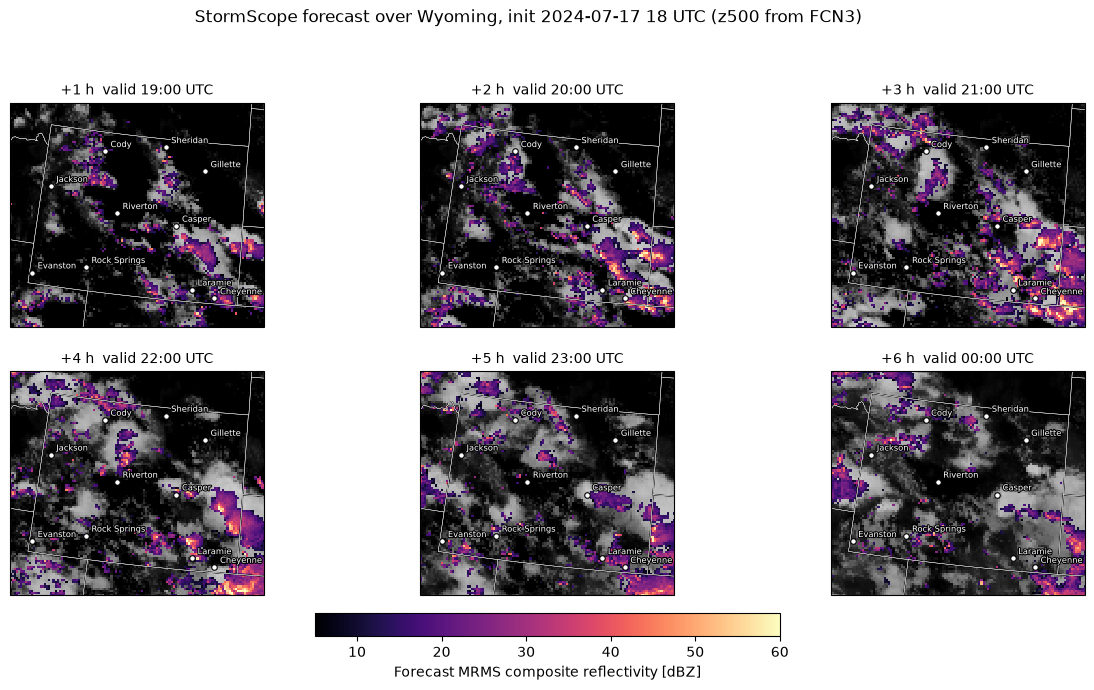

In [11]:
ncol = 3
nrow = int(np.ceil(N_STEPS / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.9 * nrow), subplot_kw=dict(projection=proj_hrrr))
for k, ax in enumerate(axes.ravel()):
    if k >= N_STEPS:
        ax.set_visible(False); continue
    im, im2 = plot_goes_mrms(ax, goes_fc[k, i_ir], mrms_fc[k, i_refc], f"+{k+1} h  valid {str(valid_times[k])[11:16]} UTC")
    ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
    add_cities(ax, fontsize=6)
fig.suptitle(f"StormScope forecast over Wyoming, init {START_TIME_STORMSCOPE:%Y-%m-%d %H} UTC (z500 from FCN3)", y=1.0)
fig.colorbar(im2, ax=axes, orientation="horizontal", shrink=0.4, pad=0.03, label="Forecast MRMS composite reflectivity [dBZ]")
plt.savefig("outputs/wyoming_hourly.png", dpi=150); plt.show()

### Verification against observed MRMS over Wyoming

Fetch the observed composite reflectivity at each valid time, regrid it with the MRMS model's own
nearest-neighbour interpolator so both fields live on the same grid, and compare inside the
Wyoming box. This is a single deterministic sample, so treat the numbers as a sanity check, not a
skill score.


In [12]:
x_obs, c_obs = fetch_data(mrms, time=time_ss, variable=np.array(["refc"]), lead_time=lead_times[1:], device=device)
x_obs = model_mrms.input_interp(x_obs.to(torch.float32))          # -> [T, L, C, H, W] on the model grid
mrms_obs = torch.where(model_mrms.valid_mask, x_obs, torch.nan)[0, :, 0].cpu().numpy()  # [N_STEPS, H, W]

wy_mask = (lat_m >= WY["lat_min"]) & (lat_m <= WY["lat_max"]) & (lon_m180 >= WY["lon_min"]) & (lon_m180 <= WY["lon_max"])
print(f"Wyoming box: {wy_mask.sum()} model grid points")

def box_stats(field):
    v = field[wy_mask]
    v = v[np.isfinite(v)]
    return dict(max_dBZ=float(np.nanmax(v)), frac_ge35=float(np.mean(v >= 35)), frac_ge20=float(np.mean(v >= 20)))

rows = []
for k in range(N_STEPS):
    f, o = box_stats(mrms_fc[k, i_refc]), box_stats(mrms_obs[k])
    rows.append(dict(lead_h=k + 1, valid=str(valid_times[k])[:16],
                     fc_max=f["max_dBZ"], obs_max=o["max_dBZ"],
                     fc_frac_ge35=f["frac_ge35"], obs_frac_ge35=o["frac_ge35"],
                     fc_frac_ge20=f["frac_ge20"], obs_frac_ge20=o["frac_ge20"]))
verif = pd.DataFrame(rows).set_index("lead_h")
verif.round(3)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff987b2fad0>


Fetching MRMS data:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching MRMS data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-01 22:28:18.005 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240717/MRMS_MergedReflectivityQCComposite_00.50_20240717-190042.grib2.gz


Fetching MRMS data: 100%|██████████| 1/1 [00:02<00:00,  2.24s/it]

...

2026-09-01 22:28:34.958 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240718/MRMS_MergedReflectivityQCComposite_00.50_20240718-000043.grib2.gz


Fetching MRMS data: 100%|██████████| 1/1 [00:05<00:00,  5.06s/it]

Fetching MRMS data: 100%|██████████| 1/1 [00:05<00:00,  5.06s/it]

Wyoming box: 7076 model grid points


,valid,fc_max,obs_max,fc_frac_ge35,obs_frac_ge35,fc_frac_ge20,obs_frac_ge20
lead_h,,,,,,,
1,2024-07-17T19:00,51.848,57.5,0.009,0.009,0.055,0.056
2,2024-07-17T20:00,65.647,57.0,0.017,0.010,0.079,0.080
3,2024-07-17T21:00,66.042,54.0,0.023,0.009,0.104,0.078
4,2024-07-17T22:00,63.425,57.5,0.016,0.008,0.077,0.074
5,2024-07-17T23:00,53.134,57.5,0.007,0.009,0.049,0.076
6,2024-07-18T00:00,63.826,49.5,0.004,0.006,0.033,0.054


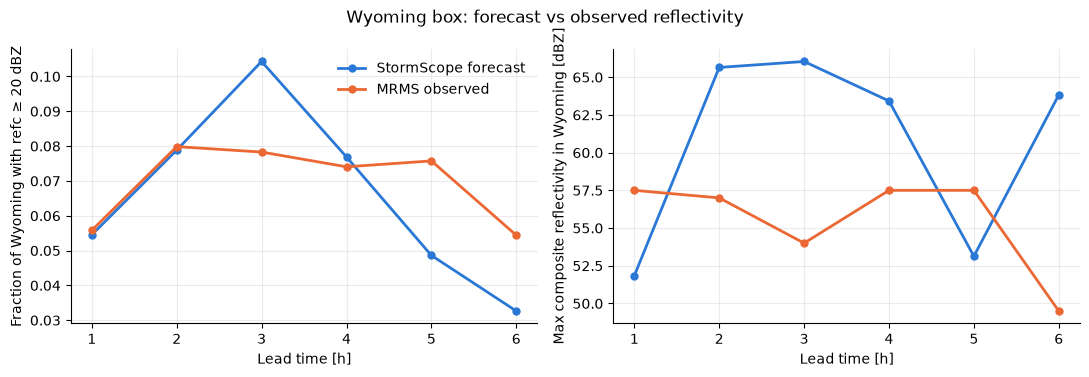

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
h = verif.index.values
for ax, col, ylabel in [(axes[0], "frac_ge20", "Fraction of Wyoming with refc ≥ 20 dBZ"),
                        (axes[1], "max_dBZ", "Max composite reflectivity in Wyoming [dBZ]")]:
    fc_col, obs_col = (f"fc_{col}", f"obs_{col}") if col != "max_dBZ" else ("fc_max", "obs_max")
    ax.plot(h, verif[fc_col], color="#2a78d6", linewidth=2, marker="o", markersize=5, label="StormScope forecast")
    ax.plot(h, verif[obs_col], color="#eb6834", linewidth=2, marker="o", markersize=5, label="MRMS observed")
    ax.set_xlabel("Lead time [h]"); ax.set_ylabel(ylabel)
    ax.set_xticks(h); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
fig.suptitle("Wyoming box: forecast vs observed reflectivity")
plt.tight_layout(); plt.savefig("outputs/wyoming_verification.png", dpi=150); plt.show()

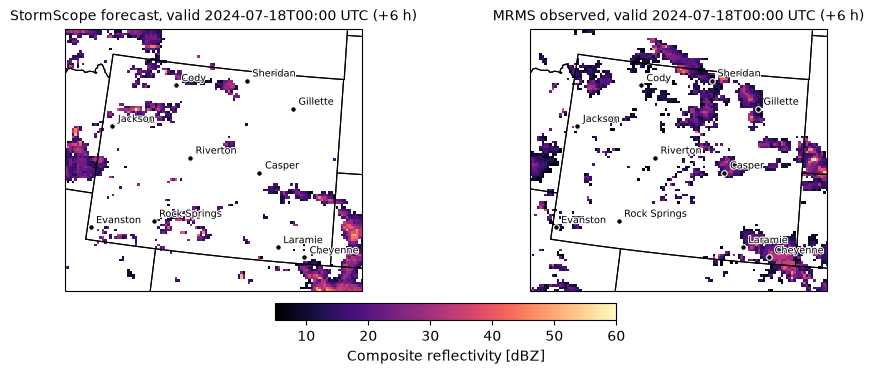

In [14]:
# Side-by-side forecast vs observed reflectivity over Wyoming at the final step
k = N_STEPS - 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), subplot_kw=dict(projection=proj_hrrr))
for ax, field, name in [(axes[0], mrms_fc[k, i_refc], "StormScope forecast"), (axes[1], mrms_obs[k], "MRMS observed")]:
    im2 = ax.pcolormesh(lon_m, lat_m, np.where(field <= 5, np.nan, field), transform=ccrs.PlateCarree(),
                        cmap="magma", shading="auto", vmin=5, vmax=60)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
    add_cities(ax, color="black", edge="white", fontsize=7)
    ax.set_title(f"{name}, valid {str(valid_times[k])[:16]} UTC (+{k+1} h)", fontsize=10)
fig.colorbar(im2, ax=axes, orientation="horizontal", shrink=0.4, pad=0.04, label="Composite reflectivity [dBZ]")
plt.savefig("outputs/wyoming_fc_vs_obs.png", dpi=150); plt.show()

### Export the Wyoming cut-out

In [15]:
ys, xs = np.where(wy_mask)
sl = (slice(ys.min(), ys.max() + 1), slice(xs.min(), xs.max() + 1))
ds_out = xr.Dataset(
    {
        **{v: (("lead_time", "y", "x"), goes_fc[:, i, sl[0], sl[1]]) for i, v in enumerate(model_goes.variables)},
        "refc": (("lead_time", "y", "x"), mrms_fc[:, i_refc, sl[0], sl[1]]),
        "refc_obs": (("lead_time", "y", "x"), mrms_obs[:, sl[0], sl[1]]),
    },
    coords=dict(
        lead_time=lead_times[1:], y=model_goes.y[sl[0]], x=model_goes.x[sl[1]],
        lat=(("y", "x"), lat_m[sl]), lon=(("y", "x"), lon_m180[sl]),
        time=np.datetime64(time_ss[0]),
    ),
    attrs=dict(
        title="StormScope 6km_1hr forecast over Wyoming, z500 conditioning from FCN3+InterpModAFNO",
        aiwp_init=str(START_TIME_AIWP), stormscope_init=str(START_TIME_STORMSCOPE), seed=SEED,
        grid="HRRR Lambert conformal, 2x downsampled (6 km)",
    ),
)
ds_out.to_netcdf("outputs/stormscope_aiwp_wyoming.nc")
ds_out

<xarray.Dataset> Size: 2MB
Dimensions:    (lead_time: 6, y: 84, x: 102)
Coordinates:
  * lead_time  (lead_time) timedelta64[s] 48B 01:00:00 02:00:00 ... 06:00:00
  * y          (y) float64 672B 2.997e+05 3.057e+05 ... 7.917e+05 7.977e+05
  * x          (x) float64 816B -1.129e+06 -1.123e+06 ... -5.285e+05 -5.225e+05
    lat        (y, x) float32 34kB 40.46 40.46 40.47 40.48 ... 45.48 45.48 45.49
    lon        (y, x) float32 34kB -110.9 -110.8 -110.7 ... -104.3 -104.2 -104.2
    time       datetime64[ns] 8B 2024-07-17T18:00:00
Data variables:
    abi01c     (lead_time, y, x) float32 206kB 0.3194 0.1403 ... 0.1569 0.1483
    abi02c     (lead_time, y, x) float32 206kB 0.2664 0.08756 ... 0.1027 0.09923
    abi03c     (lead_time, y, x) float32 206kB 0.3642 0.1753 ... 0.1561 0.1437
    abi07c     (lead_time, y, x) float32 206kB 284.4 306.8 309.9 ... 304.5 304.1
    abi08c     (lead_time, y, x) float32 206kB 233.9 236.7 238.3 ... 242.3 242.5
    abi09c     (lead_time, y, x) float32 206kB 238.5 244.0 246.2 ... 252.0 252.2
    abi10c     (lead_time, y, x) float32 206kB 242.5 250.8 253.3 ... 260.5 260.5
    abi13c     (lead_time, y, x) float32 206kB 264.8 297.0 299.4 ... 297.2 297.9
    refc       (lead_time, y, x) float32 206kB -9.797 -9.793 ... -9.803 -9.803
    refc_obs   (lead_time, y, x) float32 206kB 16.5 13.0 11.0 ... -99.0 -99.0
Attributes:
    title:            StormScope 6km_1hr forecast over Wyoming, z500 conditio...
    aiwp_init:        2024-07-17 12:00:00
    stormscope_init:  2024-07-17 18:00:00
    seed:             1234
    grid:             HRRR Lambert conformal, 2x downsampled (6 km)

## Where to go from here

* **Ensemble**: repeat the batch dimension (`x_goes.repeat(B, ...)`) and/or loop over FCN3 seeds
  with `fcn3.set_rng(seed)` to get a StormScope ensemble driven by an AIWP ensemble; the same
  structure is used by the `foundry_fcn3_stormscope_goes` serving workflow.
* **Swap the AIWP model**: any earth2studio prognostic model that outputs `z500` on a lat/lon grid
  works as the conditioning source. Models without the 73 InterpModAFNO channels can be
  interpolated in time by hand (z500 is smooth at hourly scale).
* **Longer AIWP lead**: increase the gap between `START_TIME_AIWP` and `START_TIME_STORMSCOPE` to
  see how conditioning from a day-old AIWP forecast changes the nowcast.
